In [1]:
import pandas as pd
import time
import numpy as np

data = pd.read_csv('Interactive Interval Dataset.csv')
data

,Unnamed: 0,address,to_address,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62
0,0,0x0000000048429ba5463a4a9aa866460087dcebd0,0x7cc46cf6392ed9db45351a3f82eb2cc3b83da761,355,351.0,22.0,20.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0x00000000863b56a3c1f0f1be8bc4f8b7bd78f57a,0xf89d7b9c864f589bbf53a82105107622b35eaa40,601,592.0,180.0,180.0,180.0,180.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,0x000000062bf07241987d5f1f88fc25c9190bcfc9,0x7dbfed48bddd2d4357f1f3c7dc45f5f85eb7100e,539,258.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,0x00000006e42915a2b6907f8b3faf311b68862f60,0x6448d7a20ece8c57212ad52b362b5c9b4feac27d,140,73.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0x000000697bb288f2528042e8844b65cd32beafca,0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45,564,554.0,303.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12413,12413,0xfff39900273ffb1045c7cfde62df1720b63fd6bd,0xdac17f958d2ee523a2206206994597c13d831ec7,482,470.0,460.0,438.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12414,12414,0xfff401de598bd133cff26be5e79bbee4eed2a0e4,0xdac17f958d2ee523a2206206994597c13d831ec7,500,392.0,382.0,354.0,109.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12415,12415,0xfff43d5173d5902c3f25495df374d2e6ffc84665,0xde3ccb7379d0e748fc56e964df87176eb72a28a9,610,610.0,610.0,566.0,479.0,468.0,465.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12416,12416,0xfff61e018e87e8b05549177c5c6c4d44fc984f29,NaN,604,600.0,598.0,595.0,592.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
#Delete data with fewer than 3 interactions
data = data.dropna(axis = 0,thresh=6)
data

,Unnamed: 0,address,to_address,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62
0,0,0x0000000048429ba5463a4a9aa866460087dcebd0,0x7cc46cf6392ed9db45351a3f82eb2cc3b83da761,355,351.0,22.0,20.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0x00000000863b56a3c1f0f1be8bc4f8b7bd78f57a,0xf89d7b9c864f589bbf53a82105107622b35eaa40,601,592.0,180.0,180.0,180.0,180.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0x000000697bb288f2528042e8844b65cd32beafca,0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45,564,554.0,303.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,0x000000b833f5d0d1119c479df0777789a6ac207d,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,303,285.0,278.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,0x000101d1c9769ea22d6ea627b19bffcc99f61bf3,0xdac17f958d2ee523a2206206994597c13d831ec7,130,117.0,115.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12413,12413,0xfff39900273ffb1045c7cfde62df1720b63fd6bd,0xdac17f958d2ee523a2206206994597c13d831ec7,482,470.0,460.0,438.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12414,12414,0xfff401de598bd133cff26be5e79bbee4eed2a0e4,0xdac17f958d2ee523a2206206994597c13d831ec7,500,392.0,382.0,354.0,109.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12415,12415,0xfff43d5173d5902c3f25495df374d2e6ffc84665,0xde3ccb7379d0e748fc56e964df87176eb72a28a9,610,610.0,610.0,566.0,479.0,468.0,465.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12416,12416,0xfff61e018e87e8b05549177c5c6c4d44fc984f29,NaN,604,600.0,598.0,595.0,592.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#Isolate interactive information
data1 = pd.DataFrame(data.loc[:,'Unnamed: 3':'Unnamed: 62'])
data1

,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,...,Unnamed: 53,Unnamed: 54,Unnamed: 55,Unnamed: 56,Unnamed: 57,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62
0,355,351.0,22.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,601,592.0,180.0,180.0,180.0,180.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,564,554.0,303.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,303,285.0,278.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,130,117.0,115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12413,482,470.0,460.0,438.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12414,500,392.0,382.0,354.0,109.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12415,610,610.0,610.0,566.0,479.0,468.0,465.0,463.0,459.0,457.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12416,604,600.0,598.0,595.0,592.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
def processingDelay(timeInterval):
    if len(timeInterval) == 0:
        return 0
    if len(timeInterval) == 1:
        return timeInterval[0]
    if len(timeInterval) > 1: 
        responsePop = timeInterval.pop()
        avaRespond = np.mean(timeInterval[0:len(timeInterval)])
        theDelay = (avaRespond - responsePop)/avaRespond 
        processingDelay(timeInterval)
        pdlist.append(theDelay)

In [15]:
finalList = []
for i in range(0,5882):
    incoms=data1.iloc[i].dropna().astype(int).tolist()
    list_with_diff=[]
    incoms.reverse()
    for n in range(1,len(incoms)):
        if incoms[n] - incoms[n-1] == 0:
            list_with_diff.append(1)
        else:
            list_with_diff.append(incoms[n] - incoms[n-1])
    print("Difference between adjacent elements in the list: \n",list_with_diff)
    pdlist =[]
    processingDelay(list_with_diff)
    
    finalList.append(sum(pdlist))

Difference between adjacent elements in the list: 
 [2, 329, 4]
Difference between adjacent elements in the list: 
 [1, 1, 1, 412, 9]
Difference between adjacent elements in the list: 
 [251, 10]
Difference between adjacent elements in the list: 
 [7, 18]
Difference between adjacent elements in the list: 
 [2, 13]
Difference between adjacent elements in the list: 
 [253, 14, 42, 10, 10]
Difference between adjacent elements in the list: 
 [21, 12, 5, 16, 10, 40, 55, 15, 10, 9, 31, 1, 32, 11, 10, 1, 13, 94, 22, 2, 15, 8, 6, 21, 17, 37, 25, 7, 20, 8, 11]
Difference between adjacent elements in the list: 
 [7, 5]
Difference between adjacent elements in the list: 
 [1, 1, 1, 1, 1, 7, 15, 3, 1, 11, 19]
Difference between adjacent elements in the list: 
 [1, 25, 2]
Difference between adjacent elements in the list: 
 [1, 8, 70]
Difference between adjacent elements in the list: 
 [28, 78]
Difference between adjacent elements in the list: 
 [108, 10, 205]
Difference between adjacent elements in 

IndexError: single positional indexer is out-of-bounds

In [ ]:
finalList

In [16]:
poacols = [   'Unnamed: 3','Unnamed: 4','Unnamed: 5','Unnamed: 6','Unnamed: 7','Unnamed: 8','Unnamed: 9','Unnamed: 10',
           'Unnamed: 11','Unnamed: 12','Unnamed: 13','Unnamed: 14','Unnamed: 15','Unnamed: 16','Unnamed: 17','Unnamed: 18','Unnamed: 19',
           'Unnamed: 20','Unnamed: 21','Unnamed: 22','Unnamed: 23','Unnamed: 24','Unnamed: 25','Unnamed: 26','Unnamed: 27','Unnamed: 28',
           'Unnamed: 29','Unnamed: 30','Unnamed: 31','Unnamed: 32','Unnamed: 33','Unnamed: 34','Unnamed: 35','Unnamed: 36','Unnamed: 37',
           'Unnamed: 38','Unnamed: 39','Unnamed: 40','Unnamed: 41','Unnamed: 42','Unnamed: 43','Unnamed: 44','Unnamed: 45','Unnamed: 46',
           'Unnamed: 47','Unnamed: 48','Unnamed: 49','Unnamed: 50','Unnamed: 51','Unnamed: 52','Unnamed: 53','Unnamed: 54','Unnamed: 55',
           'Unnamed: 56','Unnamed: 57','Unnamed: 58','Unnamed: 59','Unnamed: 60','Unnamed: 61','Unnamed: 62']

intervalList = np.nanmax(data[poacols],1)-np.nanmin(data[poacols],1)
intervalList.tolist()

[335.0,
 421.0,
 261.0,
 25.0,
 15.0,
 329.0,
 585.0,
 12.0,
 59.0,
 27.0,
 78.0,
 106.0,
 323.0,
 488.0,
 300.0,
 523.0,
 101.0,
 36.0,
 358.0,
 70.0,
 72.0,
 8.0,
 7.0,
 22.0,
 292.0,
 144.0,
 39.0,
 370.0,
 624.0,
 135.0,
 27.0,
 177.0,
 246.0,
 45.0,
 96.0,
 430.0,
 175.0,
 194.0,
 124.0,
 159.0,
 607.0,
 15.0,
 242.0,
 97.0,
 211.0,
 119.0,
 67.0,
 621.0,
 398.0,
 412.0,
 7.0,
 25.0,
 145.0,
 209.0,
 172.0,
 529.0,
 420.0,
 202.0,
 537.0,
 43.0,
 23.0,
 187.0,
 334.0,
 291.0,
 155.0,
 19.0,
 84.0,
 139.0,
 109.0,
 12.0,
 180.0,
 49.0,
 253.0,
 75.0,
 567.0,
 101.0,
 123.0,
 286.0,
 136.0,
 29.0,
 23.0,
 187.0,
 594.0,
 11.0,
 623.0,
 8.0,
 30.0,
 37.0,
 602.0,
 555.0,
 92.0,
 372.0,
 9.0,
 277.0,
 201.0,
 68.0,
 25.0,
 301.0,
 30.0,
 291.0,
 33.0,
 64.0,
 15.0,
 56.0,
 119.0,
 610.0,
 271.0,
 162.0,
 277.0,
 115.0,
 493.0,
 11.0,
 279.0,
 13.0,
 6.0,
 588.0,
 202.0,
 193.0,
 330.0,
 261.0,
 17.0,
 242.0,
 547.0,
 207.0,
 552.0,
 177.0,
 134.0,
 20.0,
 68.0,
 11.0,
 59.0,
 5.0,
 4.

In [17]:
dfShow = pd.DataFrame(data.loc[:,'address'])
dfShow.insert(1,'interval',intervalList)
dfShow.insert(2,'delay',finalList)

In [18]:
dfShow

,address,interval,delay
0,0x0000000048429ba5463a4a9aa866460087dcebd0,335.0,-162.524169
1,0x00000000863b56a3c1f0f1be8bc4f8b7bd78f57a,421.0,-410.086747
4,0x000000697bb288f2528042e8844b65cd32beafca,261.0,0.960159
5,0x000000b833f5d0d1119c479df0777789a6ac207d,25.0,-1.571429
7,0x000101d1c9769ea22d6ea627b19bffcc99f61bf3,15.0,-5.500000
...,...,...,...
12413,0xfff39900273ffb1045c7cfde62df1720b63fd6bd,44.0,0.795455
12414,0xfff401de598bd133cff26be5e79bbee4eed2a0e4,391.0,1.667578
12415,0xfff43d5173d5902c3f25495df374d2e6ffc84665,153.0,-22.084112
12416,0xfff61e018e87e8b05549177c5c6c4d44fc984f29,12.0,-0.166667


In [19]:
mid = dfShow['interval'].median()
mid

102.0

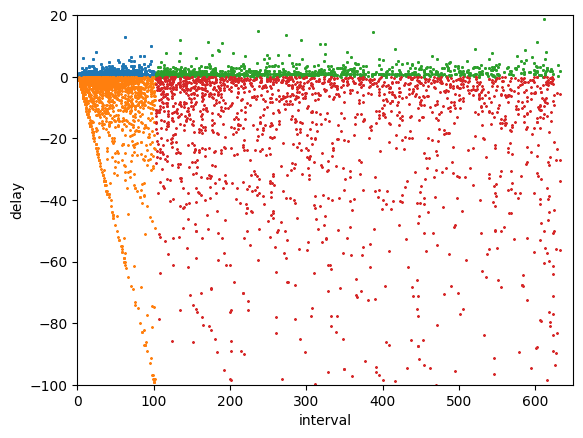

In [20]:
import matplotlib.pyplot as plt

a11 = [dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] >=0)][['interval']] for n in dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] >=0)]]
a12 = [dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] >=0)][['delay']] for n in dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] >=0)]]
a21 = [dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] <0)][['interval']] for n in dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] <0)]]
a22 = [dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] <0)][['delay']] for n in dfShow[(dfShow['interval'] <= mid) & (dfShow['delay'] <0)]]
a31 = [dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] >=0)][['interval']] for n in dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] >=0)]]
a32 = [dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] >=0)][['delay']] for n in dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] >=0)]]
a41 = [dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] < 0)][['interval']] for n in dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] < 0)]]
a42 = [dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] < 0)][['delay']] for n in dfShow[(dfShow['interval'] > mid) & (dfShow['delay'] < 0)]]

plt.scatter(a11, a12, marker='o',s=1)
plt.scatter(a21, a22, marker='x',s=1)
plt.scatter(a31, a32, marker='*',s=1)
plt.scatter(a41, a42, marker='x',s=1)

plt.xlabel("interval")
plt.xlim(0, 650)
plt.ylim(-100, 20)
plt.ylabel("delay")
plt.show()

In [21]:
dfShow[(dfShow['delay'] >=0)]

,address,interval,delay
4,0x000000697bb288f2528042e8844b65cd32beafca,261.0,0.960159
9,0x0002b5ca4da0bf9b22480a39c32145159388baed,329.0,3.407578
12,0x0010985214e2a95244b4765b7df8693d1c5c393f,12.0,0.285714
32,0x0057125e1669d2f5666a6543cf168d1388787002,101.0,0.706122
37,0x0062a46dcf81760aca47666c1ad30591126a5b1c,358.0,0.761246
...,...,...,...
12387,0xff7b7bedb4bf3e0ff5a35794494deb91daf232cd,65.0,1.236695
12398,0xffa887a4853985702f10ceb0abc6febc4f51f657,6.0,0.800000
12410,0xffeeed7021198ca17f395757d3e47e2383a367b9,47.0,0.978723
12413,0xfff39900273ffb1045c7cfde62df1720b63fd6bd,44.0,0.795455


In [22]:
pd.set_option('display.max_rows', 30)
dfShow[(dfShow['delay'] <-80)&(dfShow['interval'] >100)]

,address,interval,delay
0,0x0000000048429ba5463a4a9aa866460087dcebd0,335.0,-162.524169
1,0x00000000863b56a3c1f0f1be8bc4f8b7bd78f57a,421.0,-410.086747
69,0x00eaf6009e58c414fa5e6d10c24d24f61b905738,175.0,-82.216867
104,0x01c3a1a6890a146ac187a019f9863b3ab2bff91e,529.0,-101.518785
139,0x026b5512a46e1aef74726f5c0977743cd49a40b9,180.0,-85.186047
...,...,...,...
12225,0xfc55274d4b5e885180403584bc9a3b68022b8a25,238.0,-237.000000
12236,0xfc73960172ffbe68da16c440ade0c70bf3468337,406.0,-280.305896
12254,0xfccc5ecdb765cb32a9be3037cebda46cf73d9685,278.0,-276.000000
12309,0xfdd69dbfa0c91d83c27237883ad334702d20a949,244.0,-106.713931


In [23]:
import numpy as np
from sklearn.cluster import DBSCAN

# Construct a clusterer with ϵ=2 and MinPts=15, using Euclidean distance.
estimator_1=DBSCAN(eps=5,min_samples=12,metric='chebyshev')
# estimator_2=DBSCAN(eps=10,min_samples=20,metric='chebyshev')
# estimator_3=DBSCAN(eps=15,min_samples=15,metric='chebyshev')
# estimator_4=DBSCAN(eps=10,min_samples=15,metric='chebyshev')
# data
# dfPhoto = dfShow[(dfShow['interval']) & (dfShow['delay'])]    # 10   20 
# data8 = data6[(data6['interval'] <= mid) & (data6['delay'] >=0)]   # all
# data9 = data6[(data6['interval'] > mid) & (data6['delay'] >=0)]   # 15   15
# data10 = data6[(data6['interval'] > mid) & (data6['delay'] <0)]    # 10   15
estimator_1.fit(dfShow[['interval','delay']])
# estimator_2.fit(data8[['interval','delay']])
# estimator_3.fit(data9[['interval','delay']])
# estimator_4.fit(data10[['interval','delay']])
# 输出聚类都类别（-1代表异常点）
estimator_1.labels_
# estimator_2.labels_
# estimator_3.labels_
# estimator_4.labels_

array([-1, -1,  0, ..., -1,  0, -1], dtype=int64)

In [24]:
est = dfShow[(estimator_1.labels_ == 0)]
est1 = dfShow[(estimator_1.labels_ == -1) | (estimator_1.labels_ > 0)]

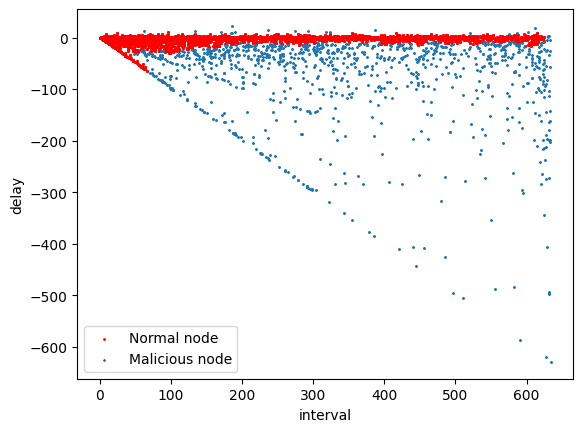

In [25]:
import matplotlib.pyplot as plt
# Retrieve data from the first and second columns Use a for loop to retrieve n[0] represents the first column of X
x = [est[['interval']] for n in est]
z = [est1[['interval']] for n in est1]
# b = [est2[['interval']] for n in est2]
# d = [est3[['interval']] for n in est3]

y = [est[['delay']] for n in est]
a = [est1[['delay']] for n in est1]
# c = [est2[['delay']] for n in est2]
# e = [est3[['delay']] for n in est3]
# Plot a scatter plot Parameters: x - horizontal axis y - vertical axis c = y_pred - cluster prediction results Marker type: o - dot * - star x - x-axis
plt.scatter(x, y, marker='o',s=1,c='r')
plt.scatter(z, a, marker='x',s=1)
# plt.scatter(b, c, marker='o',s=1)
# plt.scatter(d, e, marker='o',s=1,c='black')

# plt.xlim(0, 650)
# plt.ylim(-80, 20)
plt.xlabel("interval")
plt.ylabel("delay")
plt.legend(["Normal node","Malicious node"])
# plt.savefig('distinctions2.png',dpi=300,format="png")
# 显示图形
plt.show()